In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [2]:

data = load_iris()

X = data.data
y = data.target

print("Dataset size:", len(X))
print("Number of features:", X.shape[1])
print("Number of classes:", len(np.unique(y)))

Dataset size: 150
Number of features: 4
Number of classes: 3


If we increase the validation set percentage, the validation accuracy becomes more reliable because it is calculated using more samples. However, fewer samples are left for training.

If we reduce the validation set percentage, more data is available for training, but the validation accuracy becomes less reliable because it is calculated using fewer samples.

For very small validation sets such as 0.1%, the accuracy can vary greatly because even one incorrectly classified sample can significantly change the accuracy.

For very large validation sets such as 99.9%, there is almost no data left for training, so the classifier may perform poorly.
A reasonable choice is generally around 10% to 20% validation data.

In [3]:
splits = [0.1, 0.2, 0.3, 0.5, 0.9]

acc_1nn = []
acc_3nn = []

for split in splits:
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=split, random_state=42, stratify=y
    )
    model1 = KNeighborsClassifier(n_neighbors=1)
    model1.fit(X_train, y_train)
    pred1 = model1.predict(X_val)
    acc_1nn.append(accuracy_score(y_val, pred1))

    model3 = KNeighborsClassifier(n_neighbors=3)
    model3.fit(X_train, y_train)
    pred3 = model3.predict(X_val)
    acc_3nn.append(accuracy_score(y_val, pred3))

print("Validation Split:", splits)
print("1-NN Accuracy:", acc_1nn)
print("3-NN Accuracy:", acc_3nn)

Validation Split: [0.1, 0.2, 0.3, 0.5, 0.9]
1-NN Accuracy: [1.0, 0.9666666666666667, 0.9333333333333333, 0.96, 0.9555555555555556]
3-NN Accuracy: [1.0, 1.0, 0.9555555555555556, 0.92, 0.9333333333333333]


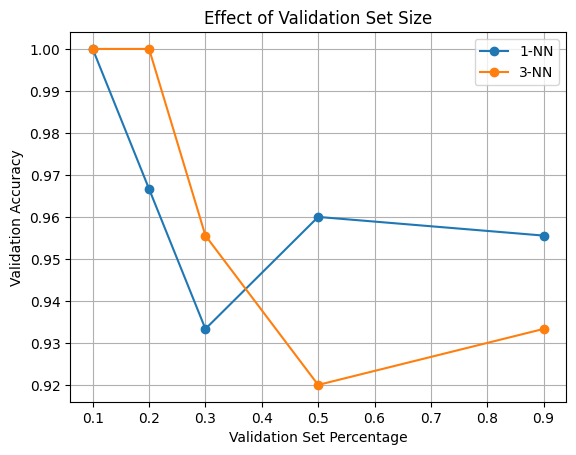

In [4]:
plt.plot(splits, acc_1nn, marker='o', label='1-NN')
plt.plot(splits, acc_3nn, marker='o', label='3-NN')

plt.xlabel("Validation Set Percentage")
plt.ylabel("Validation Accuracy")
plt.title("Effect of Validation Set Size")
plt.legend()
plt.grid()
plt.show()

When the validation set is increased, more samples are available for evaluating the model, so the validation accuracy becomes more representative.

However, increasing the validation set also decreases the training set size. Since nearest neighbour classifiers depend directly on the training samples, a very small training set can reduce their performance.

Therefore, a balance is required between training and validation data.

A validation set of around 10% to 20% is a reasonable choice for this experiment.

A random classifier does not learn from the training data. It randomly predicts one of the available classes.

Therefore, changing the training-set size does not significantly affect its performance. However, the size of the validation set affects how reliable the measured accuracy is.

A small validation set can give highly variable results, while a larger validation set gives a more stable estimate of the random classifier's accuracy.

In [5]:
def random_classifier(X):
    return np.random.choice(np.unique(y), size=len(X))

random_acc = []

for split in splits:
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=split, random_state=42, stratify=y
    )

    pred = random_classifier(X_val)
    random_acc.append(accuracy_score(y_val, pred))

print("Random Classifier Accuracy:", random_acc)

Random Classifier Accuracy: [0.3333333333333333, 0.26666666666666666, 0.35555555555555557, 0.24, 0.32592592592592595]


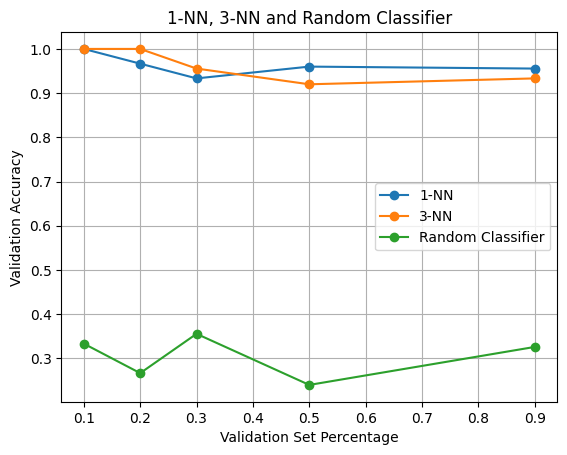

In [6]:
plt.plot(splits, acc_1nn, marker='o', label='1-NN')
plt.plot(splits, acc_3nn, marker='o', label='3-NN')
plt.plot(splits, random_acc, marker='o', label='Random Classifier')

plt.xlabel("Validation Set Percentage")
plt.ylabel("Validation Accuracy")
plt.title("1-NN, 3-NN and Random Classifier")
plt.legend()
plt.grid()
plt.show()

We also test extreme validation set sizes such as 0.1% and 99.9%.

With 0.1% validation data, the validation set is extremely small, so its accuracy is not a reliable estimate.

With 99.9% validation data, almost the entire dataset is used for validation and almost no data is available for training. Therefore, the nearest neighbour classifier cannot learn effectively.

These extreme cases demonstrate why a balanced train-validation split is necessary.

In [7]:
extreme_splits = [0.001, 0.01, 0.1, 0.2, 0.5, 0.9, 0.99]

for split in extreme_splits:
    try:
        X_train, X_val, y_train, y_val = train_test_split(
            X, y, test_size=split, random_state=42, stratify=y
        )

        model = KNeighborsClassifier(n_neighbors=1)
        model.fit(X_train, y_train)

        pred = model.predict(X_val)
        acc = accuracy_score(y_val, pred)

        print("Validation split:", split, "Accuracy:", acc)

    except Exception as e:
        print("Validation split:", split, "Error:", e)

Validation split: 0.001 Error: The test_size = 1 should be greater or equal to the number of classes = 3
Validation split: 0.01 Error: The test_size = 2 should be greater or equal to the number of classes = 3
Validation split: 0.1 Accuracy: 1.0
Validation split: 0.2 Accuracy: 0.9666666666666667
Validation split: 0.5 Accuracy: 0.96
Validation split: 0.9 Accuracy: 0.9555555555555556
Validation split: 0.99 Error: The train_size = 1 should be greater or equal to the number of classes = 3


## Exercise: 1-NN vs 3-NN

A 1-NN classifier uses only the closest training point to make a prediction.

A 3-NN classifier considers the three closest training points and uses majority voting.

The 3-NN classifier can be less sensitive to noise because it considers multiple neighbours instead of only one.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 1-NN
model1 = KNeighborsClassifier(n_neighbors=1)
model1.fit(X_train, y_train)

pred1 = model1.predict(X_test)
accuracy1 = accuracy_score(y_test, pred1)

# 3-NN
model3 = KNeighborsClassifier(n_neighbors=3)
model3.fit(X_train, y_train)

pred3 = model3.predict(X_test)
accuracy3 = accuracy_score(y_test, pred3)

print("1-NN Test Accuracy:", accuracy1)
print("3-NN Test Accuracy:", accuracy3)

1-NN Test Accuracy: 0.9666666666666667
3-NN Test Accuracy: 1.0


## Exercise: Averaging Validation Accuracy Across Multiple Splits

We repeat the experiment several times using different train-validation splits.

Averaging the validation accuracy over multiple splits gives a more consistent estimate because it reduces the effect of one particular random split.

In [9]:
def multiple_splits(iterations, k=1):
    accuracies = []

    for i in range(iterations):
        X_train, X_val, y_train, y_val = train_test_split(
            X, y, test_size=0.2, random_state=i, stratify=y
        )

        model = KNeighborsClassifier(n_neighbors=k)
        model.fit(X_train, y_train)

        pred = model.predict(X_val)
        accuracies.append(accuracy_score(y_val, pred))

    return np.mean(accuracies)


for iterations in [1, 5, 10, 20, 50]:
    avg = multiple_splits(iterations, k=1)
    print("Iterations:", iterations, "Average Accuracy:", avg)

Iterations: 1 Average Accuracy: 0.9666666666666667
Iterations: 5 Average Accuracy: 0.9533333333333334
Iterations: 10 Average Accuracy: 0.9566666666666667
Iterations: 20 Average Accuracy: 0.9683333333333332
Iterations: 50 Average Accuracy: 0.9566666666666667


### Answers

### 1. Does averaging validation accuracy across multiple splits give more consistent results?

Yes. Different train-validation splits can produce different validation accuracies. Averaging the results across multiple splits reduces the effect of a particular random split and gives a more stable estimate.

### 2. Does it give a more accurate estimate of test accuracy?

Generally, yes. Averaging over multiple representative splits usually gives a better estimate of the expected model performance than using only one split. However, it does not guarantee that the estimate will exactly match the test accuracy.

### 3. What is the effect of the number of iterations?

Increasing the number of iterations generally makes the average validation accuracy more stable. The improvement becomes smaller after a sufficiently large number of iterations.

### 4. Can we deal with a very small training or validation dataset by increasing the iterations?

No. Increasing the number of iterations does not create additional data. It only reduces the effect of random splitting. A very small training set can still result in a poorly trained model, and a very small validation set can still give an unreliable accuracy estimate.

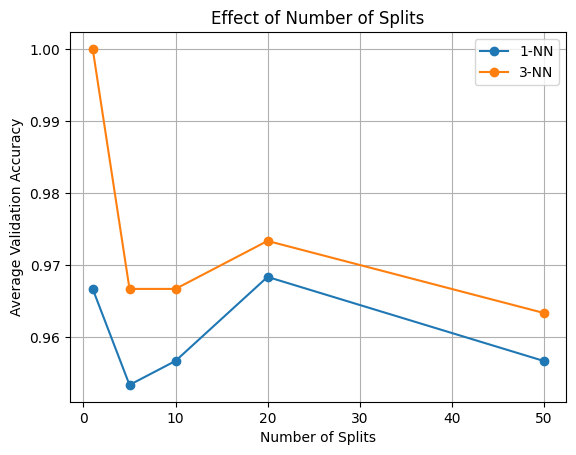

In [10]:
iterations_list = [1, 5, 10, 20, 50]

avg_1nn = []
avg_3nn = []

for n in iterations_list:
    avg_1nn.append(multiple_splits(n, k=1))
    avg_3nn.append(multiple_splits(n, k=3))

plt.plot(iterations_list, avg_1nn, marker='o', label='1-NN')
plt.plot(iterations_list, avg_3nn, marker='o', label='3-NN')

plt.xlabel("Number of Splits")
plt.ylabel("Average Validation Accuracy")
plt.title("Effect of Number of Splits")
plt.legend()
plt.grid()
plt.show()